In [24]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel,Field
load_dotenv()


True

In [25]:
model=ChatOpenAI(model="gpt-4o-mini")

In [26]:
# For Structured Output
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Feedback of the essay")
    score:int=Field(description="Score out of 10.")

In [27]:
Structured_model=model.with_structured_output(EvaluationSchema)

In [28]:
essay = """
The Silent Power of Small Habits

In a world obsessed with big achievements, overnight success, and dramatic transformations, the true engine of long-term change often goes unnoticed—small, consistent habits. These seemingly insignificant actions, repeated daily, quietly shape our lives in ways that are far more powerful than occasional bursts of motivation or effort.

At first glance, small habits appear too trivial to matter. Drinking an extra glass of water, reading a few pages of a book, or taking a short walk each day does not seem like it would drastically change one’s life. However, the real power of habits lies in their compounding effect. Just as money grows with compound interest, habits multiply their impact over time. A person who reads ten pages a day will finish around 12–15 books a year—far more than someone who waits for the “right time” to read.

One of the key reasons small habits are so effective is that they are sustainable. Big goals often fail because they demand too much change at once. People get overwhelmed, lose motivation, and eventually give up. In contrast, small habits require minimal effort and are easier to integrate into daily life. This makes them more likely to stick. Over time, these small actions become automatic, forming a strong foundation for personal growth.

Another important aspect of habits is identity. Every action we take is a vote for the type of person we want to become. For example, when someone chooses to exercise regularly, even for just 10 minutes, they begin to see themselves as a healthy and disciplined person. This shift in identity is powerful because it influences future behavior. Instead of forcing themselves to act, they naturally align with their self-image.

Moreover, small habits help reduce the pressure of perfection. Many people hesitate to start something because they feel they need to do it perfectly. However, habits encourage progress over perfection. Even a small step forward is better than no step at all. This mindset reduces fear and builds confidence, making it easier to stay consistent.

Technology and modern lifestyles often distract us from the importance of consistency. We seek quick results, instant gratification, and rapid success. But meaningful change does not happen overnight. It is the result of repeated actions, often done when no one is watching. The student who studies a little every day, the athlete who trains consistently, and the artist who practices regularly all rely on habits rather than sudden inspiration.

However, it is also important to recognize that habits can work both ways. Just as good habits can improve our lives, bad habits can slowly damage them. Skipping exercise, procrastinating, or spending excessive time on distractions may not seem harmful in the short term, but their effects accumulate over time. Therefore, being mindful of our daily actions is crucial.

Building good habits requires patience and awareness. It often helps to start small, stay consistent, and gradually increase the intensity. Environment also plays a key role. By surrounding ourselves with positive influences and reducing distractions, we make it easier to stick to our habits.

In conclusion, small habits are the silent architects of our lives. They may not bring immediate results, but their long-term impact is profound. By focusing on consistency rather than intensity, and progress rather than perfection, we can harness the true power of habits to create meaningful and lasting change.
"""

In [29]:
from typing import TypedDict,Annotated
import operator


class EssayState(TypedDict):
    essay_txt:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float

In [30]:
def evaluate_language(state:EssayState)->EssayState:
    prompt = f"Evaluate the language qualtiy of the following essay and provide a feedback and assign a score out of 10. \n{state['essay_txt']}"
    output=Structured_model.invoke(prompt)
    return {"language_feedback":output.feedback,"individual_scores":[output.score]}


def evaluate_thought(state:EssayState)->EssayState:
    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10. \n{state['essay_txt']}"
    output=Structured_model.invoke(prompt)
    return {"clarity_feedback":output.feedback,"individual_scores":[output.score]}

def evaluate_analysis(state:EssayState)->EssayState:
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10. \n{state['essay_txt']}"
    output=Structured_model.invoke(prompt)
    return {"analysis_feedback":output.feedback,"individual_scores":[output.score]}

def final_evaluation(state:EssayState)->EssayState:

    # Summarised Feedback
    prompt = f"Based on the following feedbacks create a summarised feedback.\n Language feedback->{state['language_feedback']}\n Clarity of thought feedback->{state['clarity_feedback']}\n Depth of analysis feedback->{state['analysis_feedback']}"

    overall_feedback=model.invoke(prompt).content

    # Average Score
    avg_score = sum(state["individual_scores"]) / len(state["individual_scores"])
    return {"overall_feedback":overall_feedback,"avg_score":avg_score}

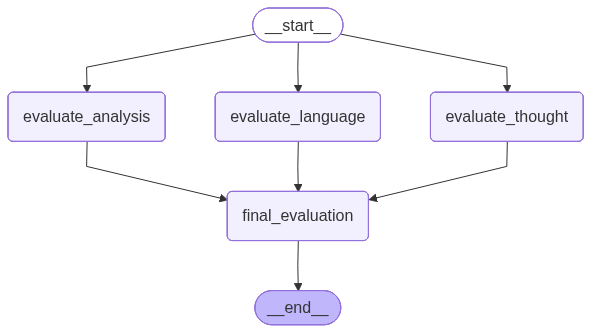

In [32]:
graph=StateGraph(EssayState)
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("final_evaluation", final_evaluation)

graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START, "evaluate_thought")
graph.add_edge(START, "evaluate_language")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("final_evaluation", END)
workflow=graph.compile()
workflow

In [ ]:
initial_state={"essay_txt":essay}
result=workflow.invoke(initial_state)
print(result)

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback... perspective.', score=8), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...s its points.', score=8), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - s

{'essay_txt': '\nThe Silent Power of Small Habits\n\nIn a world obsessed with big achievements, overnight success, and dramatic transformations, the true engine of long-term change often goes unnoticed—small, consistent habits. These seemingly insignificant actions, repeated daily, quietly shape our lives in ways that are far more powerful than occasional bursts of motivation or effort.\n\nAt first glance, small habits appear too trivial to matter. Drinking an extra glass of water, reading a few pages of a book, or taking a short walk each day does not seem like it would drastically change one’s life. However, the real power of habits lies in their compounding effect. Just as money grows with compound interest, habits multiply their impact over time. A person who reads ten pages a day will finish around 12–15 books a year—far more than someone who waits for the “right time” to read.\n\nOne of the key reasons small habits are so effective is that they are sustainable. Big goals often fa